In [1]:
import os 
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from utils import * 

# 1D cases analysis

In [2]:
log1d_paths = glob.glob('../logs/exp1d/*/*/*.csv')
plog1d_paths = glob.glob('../plogs/*/*/*/*.json')

In [3]:
log1d_df = load_accuracy_log(log1d_paths)

100%|██████████| 18319/18319 [00:50<00:00, 364.03it/s] 


In [4]:
plog1d_df = load_profile_log(plog1d_paths)

100%|██████████| 855/855 [00:00<00:00, 7428.48it/s]


In [5]:
merged_df = pd.merge(log1d_df, plog1d_df, on=['model', 'coarse_level', 'resolution', 'residual'])

## filt useless result from test_l2

### trend on different residual type without coarsen

In [6]:
log1d_filt_df, not_enough1d = log_filt_1d(merged_df)

### All type model with all type residuals and no coarsen on 4096

- model : fno1d, ft1d, gt1d, lno1d
- dataset : burgers, cosine, lnabs
- residuals : null, diag, ml1, ml2, ml3, ml4 
- resolution : 4096

In [7]:
sub_df = log1d_filt_df[(log1d_filt_df.resolution == 2048) & (log1d_filt_df.coarse_level == 0)]
table_4096_c0 = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['residual'])
column_order = ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']
table_4096_c0.reindex(column_order, axis=1).round(4)

residual         null    diag     ml1     ml2     ml3     ml4
dataset model                                                
burgers fno1d  0.0050  0.0040  0.0043  0.0046  0.0050  0.0052
        ft1d   0.0284  0.0275  0.0266  0.0221  0.0191  0.0137
        gt1d   0.0344  0.0384  0.0362  0.0355  0.0226  0.0165
        lno1d  0.0443  0.0225  0.0223  0.0249  0.0258  0.0305
cosine  fno1d  0.0205  0.0238  0.0227  0.0223  0.0218  0.0236
        ft1d   0.0217  0.0138  0.0135  0.0130  0.0116  0.0110
        gt1d   0.0363  0.0251  0.0215  0.0249  0.0203  0.0176
        lno1d  0.0439  0.0058  0.0056  0.0060  0.0080  0.0080
lnabs   fno1d  0.0178  0.0128  0.0112  0.0105  0.0105  0.0103
        ft1d   0.0415  0.0380  0.0378  0.0356  0.0247  0.0105
        gt1d   0.0393  0.0334  0.0310  0.0251  0.0201  0.0139
        lno1d  0.0606  0.0244  0.0267  0.0228  0.0197  0.0159

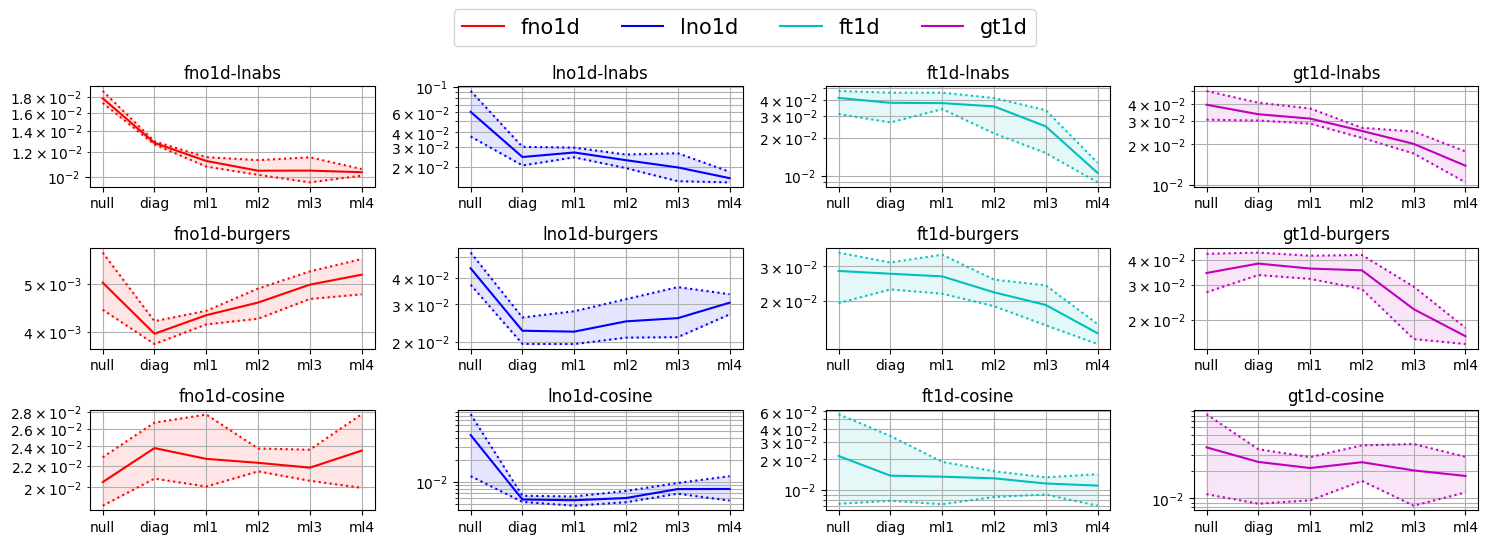

In [8]:
fig = vis_acc_model_ds1d_ml_fixres(log1d_filt_df, resolution=2048, clevel=0)

- for smooth kernel integral(cosine), we didn't observe the significance of using residuals correction.
- for singular smooth kernel intergal(lnabs), we observe the significance of using residuals, and more level correction we use the better result we will get
- for learning solution operator of burgres' equation, we observe the significance of using residuals on ft/gt

since the method we use to approximate gloabl kernel integral operation if different, the performance of residual correction operation will behave a little bit different.

### All type model with all coarsen and diag-ml4 on 4096

In [9]:
sub_df = log1d_filt_df[(log1d_filt_df.resolution == 2048) & (log1d_filt_df.residual == 'diag')]
table_mean = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.mean)
table_mean.round(4)

coarse_level        0       1       2       3       4
dataset model                                        
burgers fno1d  0.0040  0.0040  0.0040  0.0040  0.0042
        ft1d   0.0275  0.0288  0.0271  0.0286  0.0332
        gt1d   0.0384  0.0349  0.0365  0.0352  0.0335
        lno1d  0.0225  0.0217  0.0211  0.0223  0.0236
cosine  fno1d  0.0238  0.0232  0.0254  0.0313  0.0453
        ft1d   0.0138  0.0111  0.0169  0.0257  0.0460
        gt1d   0.0251  0.0212  0.0254  0.0363  0.0563
        lno1d  0.0058  0.0079  0.0114  0.0209  0.0405
lnabs   fno1d  0.0128  0.0132  0.0153  0.0206  0.0331
        ft1d   0.0380  0.0422  0.0436  0.0447  0.0424
        gt1d   0.0334  0.0315  0.0339  0.0421  0.0501
        lno1d  0.0244  0.0247  0.0255  0.0286  0.0376

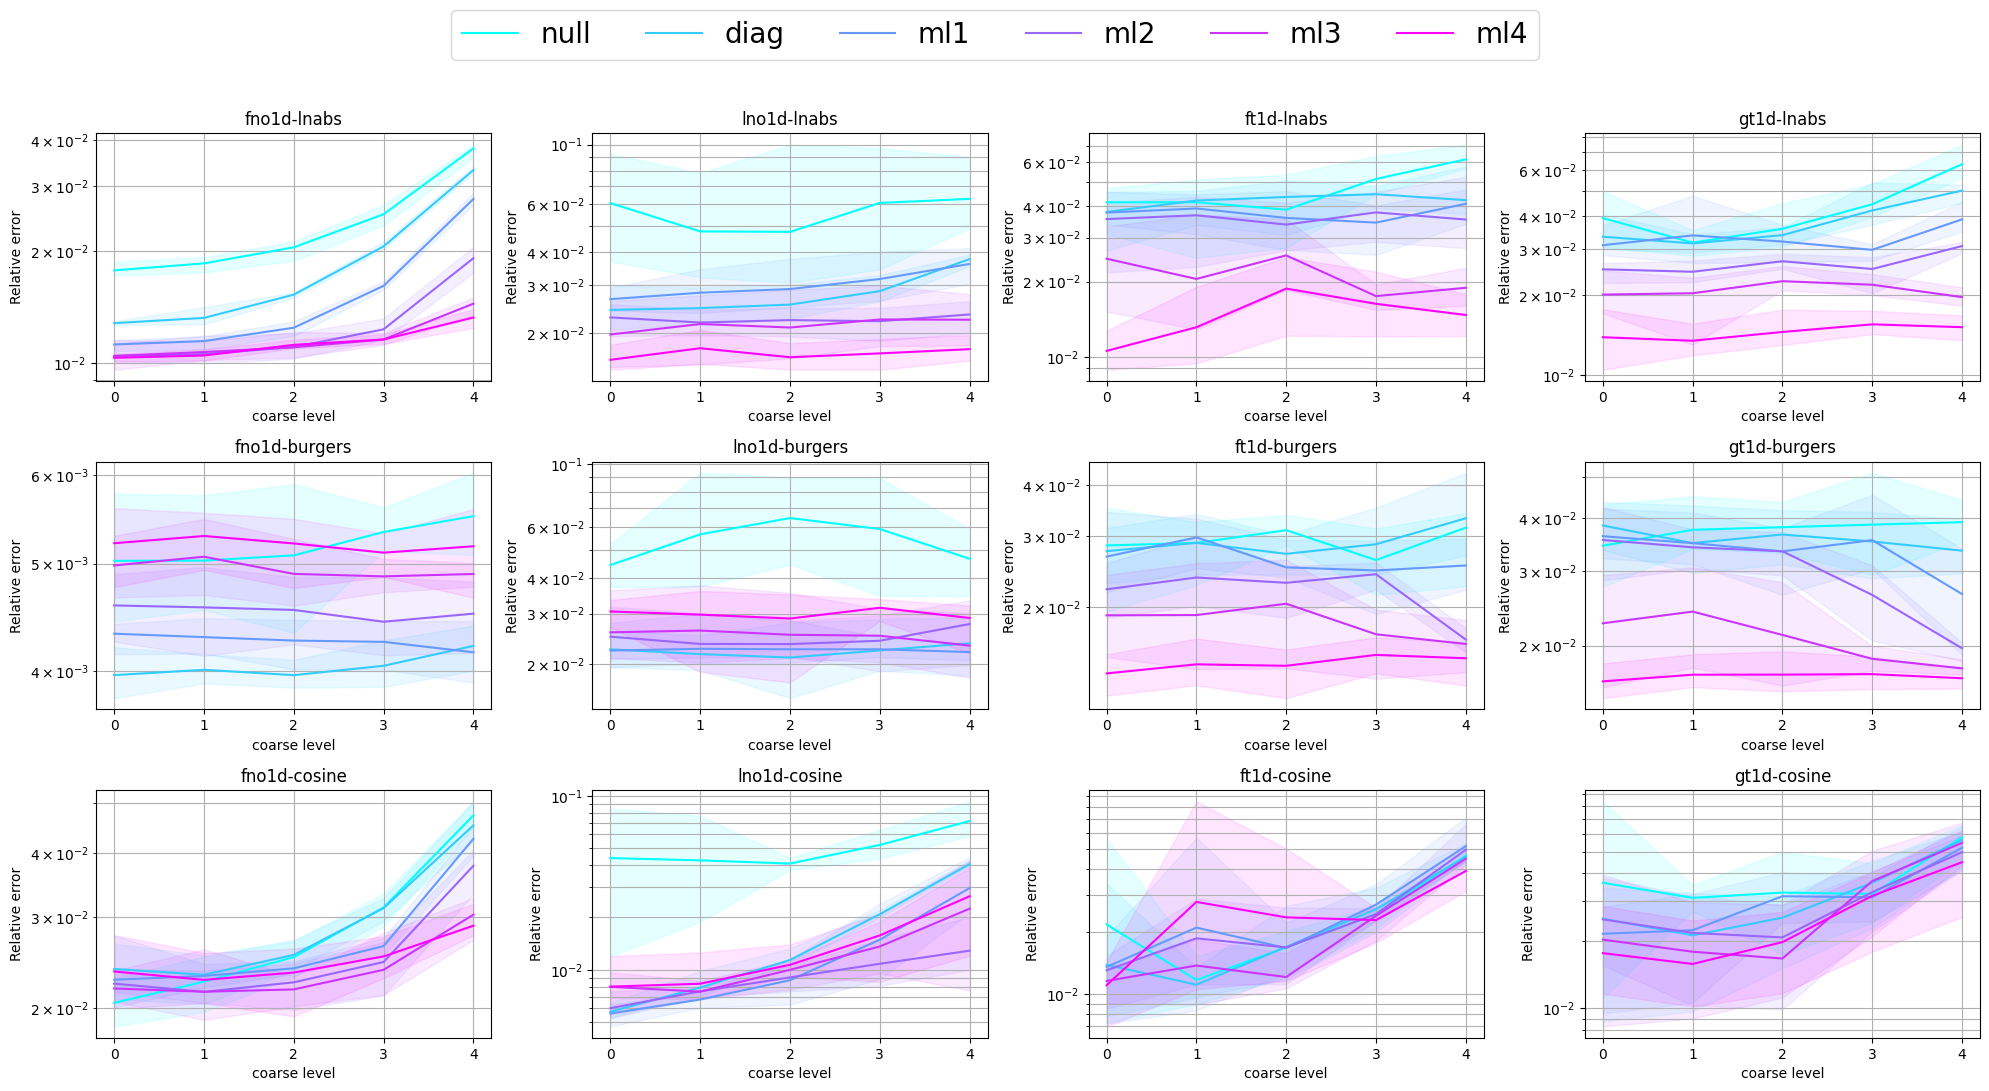

In [10]:
vis_acc_model_ds1d_ml_cl_fixres(log1d_filt_df, resolution=2048)

### trend on same resolution with different coarsen level

## Speed and Accuracy plot

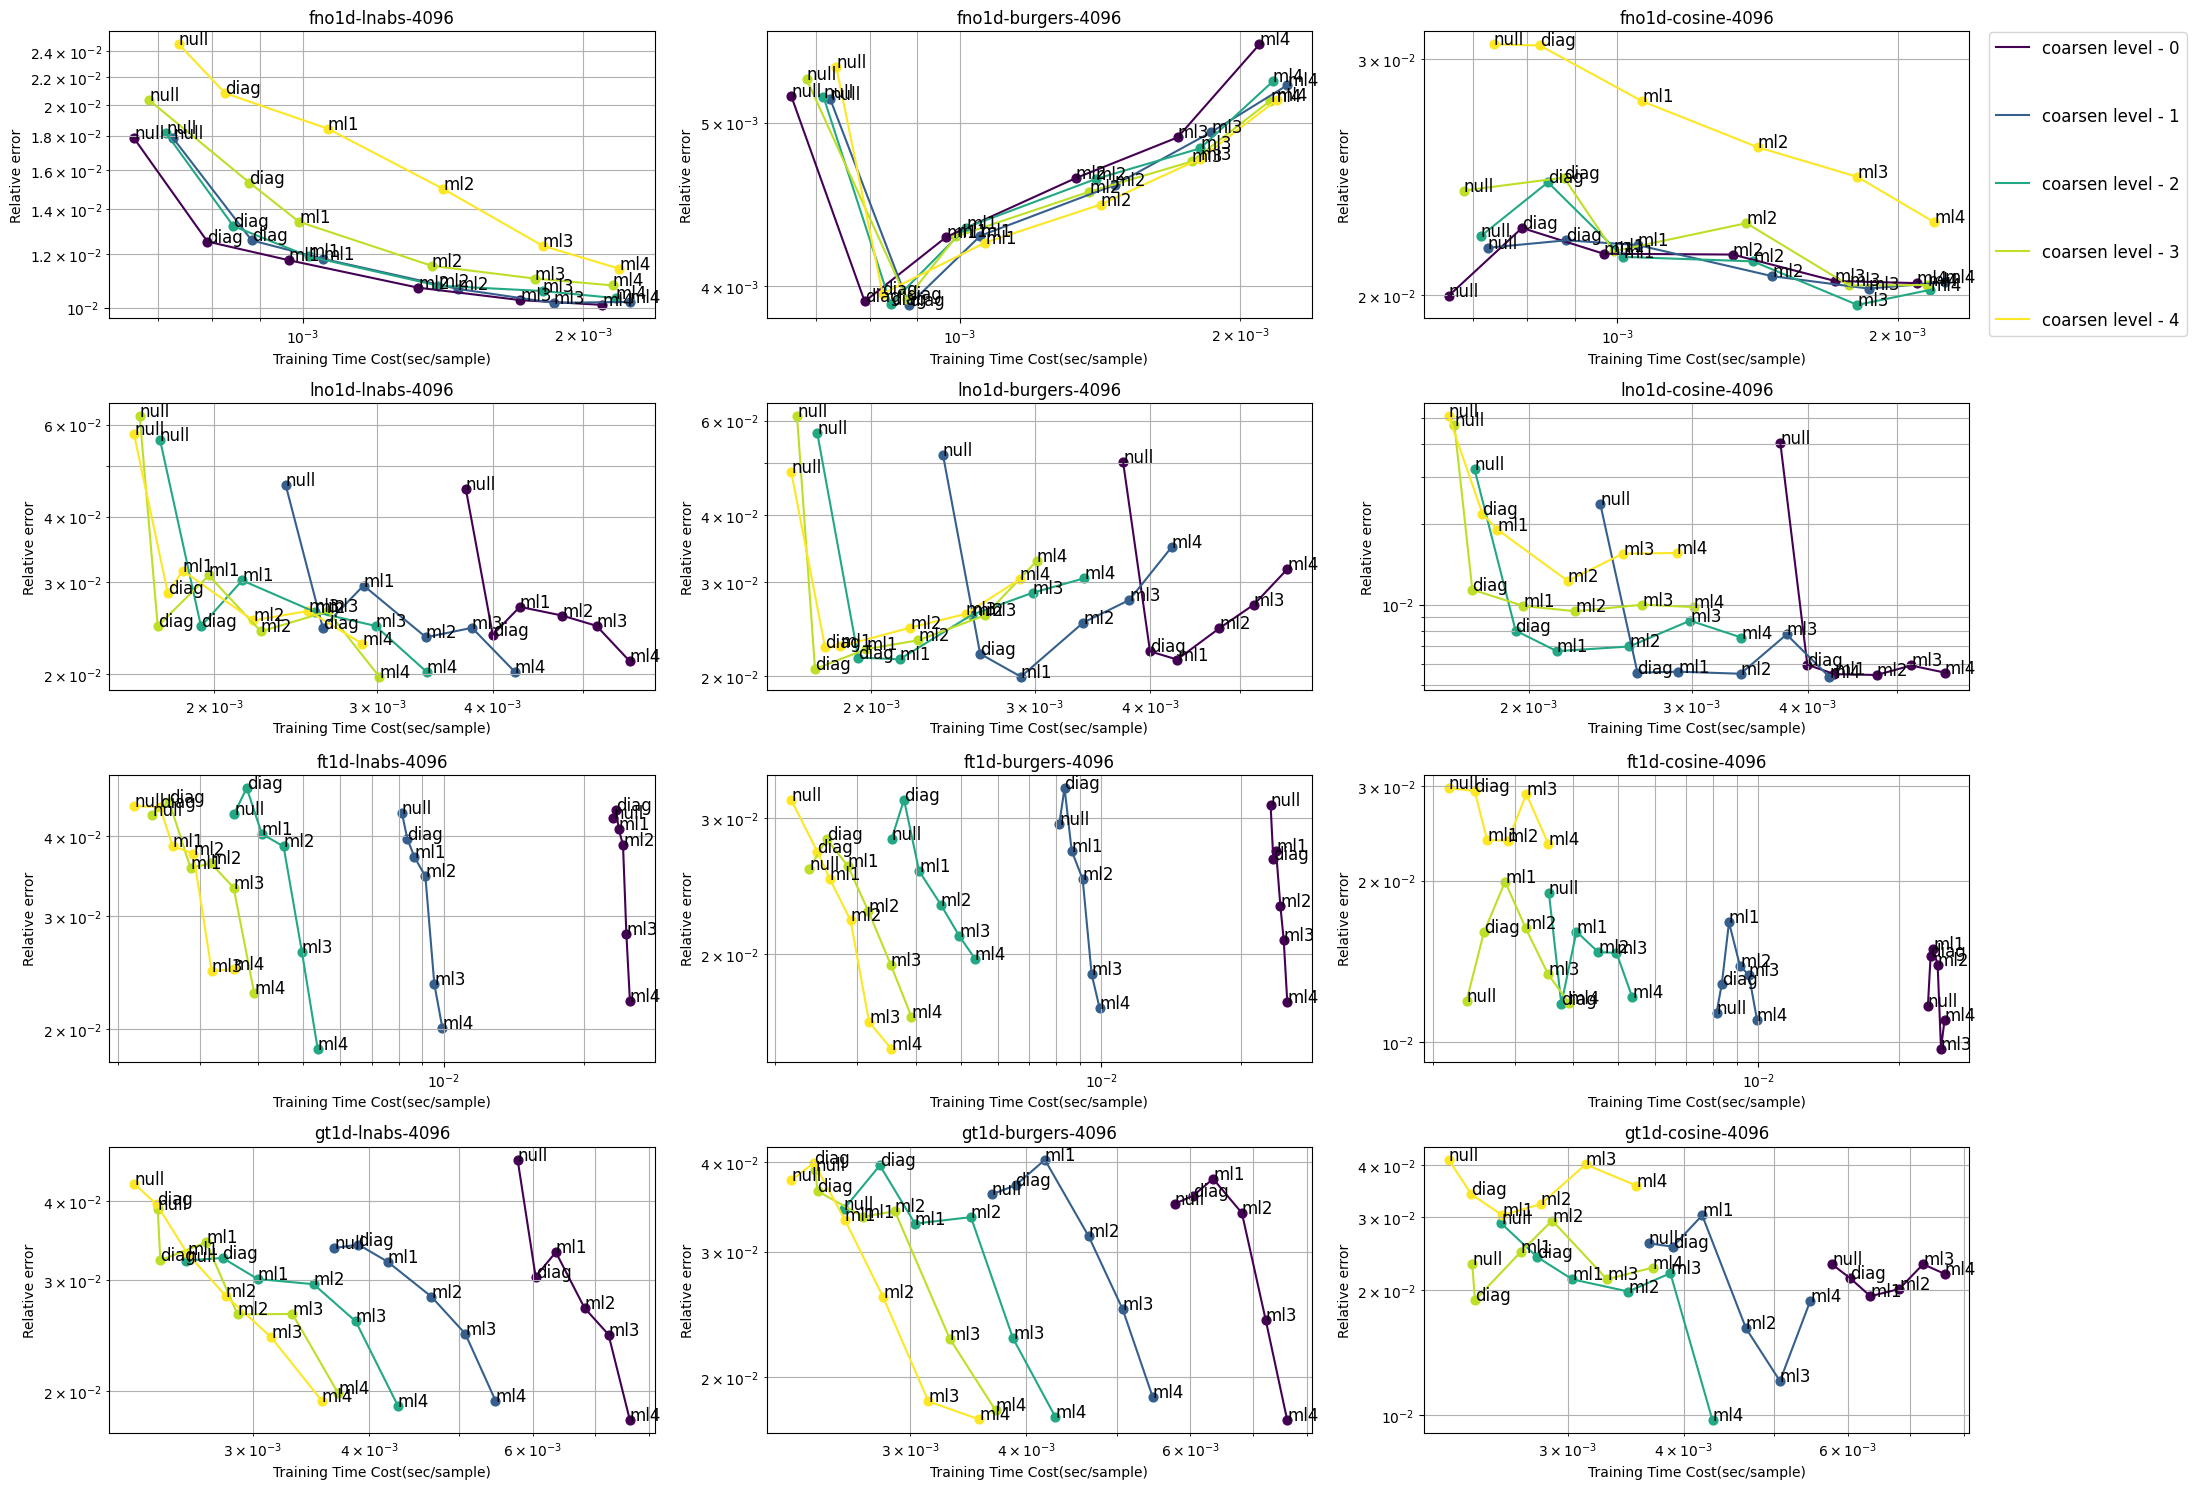

In [11]:
fig = vis_acc_cost_model_ds1d_ml_cl_fixres(log1d_filt_df, resolution=4096)

### trend on different residual type on different coarsen level

# 2D cases analysis

In [4]:
log2d_paths = glob.glob('../logs/exp2d/*/*/*.csv')
log2d_df = load_accuracy_log(log2d_paths)

  0%|          | 0/6557 [00:00<?, ?it/s]

100%|██████████| 6557/6557 [00:20<00:00, 318.55it/s]


In [5]:
log2d_filt_df, not_enough2d = log_filt_2d(log2d_df, min_nexp=5, n=0)

  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem
  : out of A100 mem


In [8]:
not_enough2d

,model_nm,dataset,coarse_level,residual,resolution,seeds
0,fno2d,darcy,0,ml1,421,"[3, 1, 0, 4]"
1,fno2d,darcy,0,ml2,421,"[0, 3]"
2,fno2d,darcy,0,ml3,421,"[0, 3]"
3,fno2d,invdist,0,ml1,421,"[0, 1, 4, 3]"
4,fno2d,invdist,0,ml2,421,"[3, 0]"
5,fno2d,invdist,0,ml3,421,"[3, 0]"
6,gt2d,darcy,0,null,421,[]
7,gt2d,darcy,0,diag,421,[]
8,gt2d,darcy,0,ml1,421,[]
9,gt2d,darcy,0,ml2,421,[]


### trend on different residual type without coarsen

In [6]:
sub_df = log2d_filt_df[(log2d_filt_df.resolution == 211) & (log2d_filt_df.coarse_level == 0)]
table_141_c0 = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['residual'])
column_order = ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']
table_141_c0.reindex(column_order, axis=1).round(4)

residual         null    diag     ml1     ml2     ml3  ml4
dataset model                                             
darcy   fno2d  0.0322  0.0131  0.0112  0.0107  0.0110  NaN
        gt2d   0.0469  0.0972  0.0242  0.0165  0.0127  NaN
        lno2d  0.0686  0.0296  0.0246  0.0210  0.0159  NaN
invdist fno2d  0.0328  0.0024  0.0023  0.0025  0.0025  NaN
        gt2d   0.0125  0.0155  0.0064  0.0044  0.0033  NaN
        lno2d  0.0310  0.0098  0.0063  0.0050  0.0038  NaN

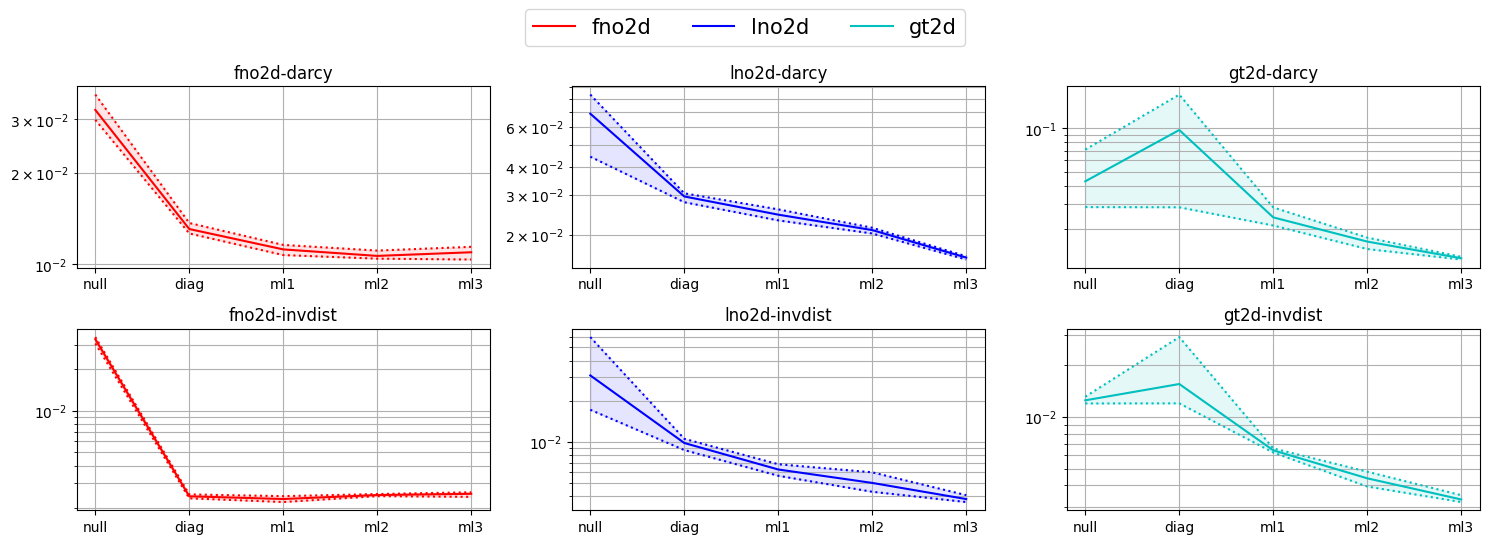

In [7]:
fig = vis_acc_model_ds2d_ml_fixres(log2d_filt_df, resolution=211, clevel=0, isft=False)

### All type model with all coarsen and diag on 141

In [9]:
sub_df = log2d_filt_df[(log2d_filt_df.resolution == 211) & (log2d_filt_df.residual == 'diag')]
table_mean = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.mean)
table_min = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.min)
table_max = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.max)

In [10]:
table_mean.round(4)

coarse_level        0       1       2       3
dataset model                                
darcy   fno2d  0.0131  0.0129  0.0142  0.0198
        ft2d      NaN  0.0348  0.0282  0.0292
        gt2d   0.0972  0.0275  0.0282  0.0293
        lno2d  0.0296  0.0283  0.0285  0.0296
invdist fno2d  0.0024  0.0032  0.0059  0.0130
        ft2d      NaN  0.0104  0.0107  0.0157
        gt2d   0.0155  0.0103  0.0109  0.0159
        lno2d  0.0098  0.0090  0.0107  0.0150

### trend on same resolution with different coarsen level

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

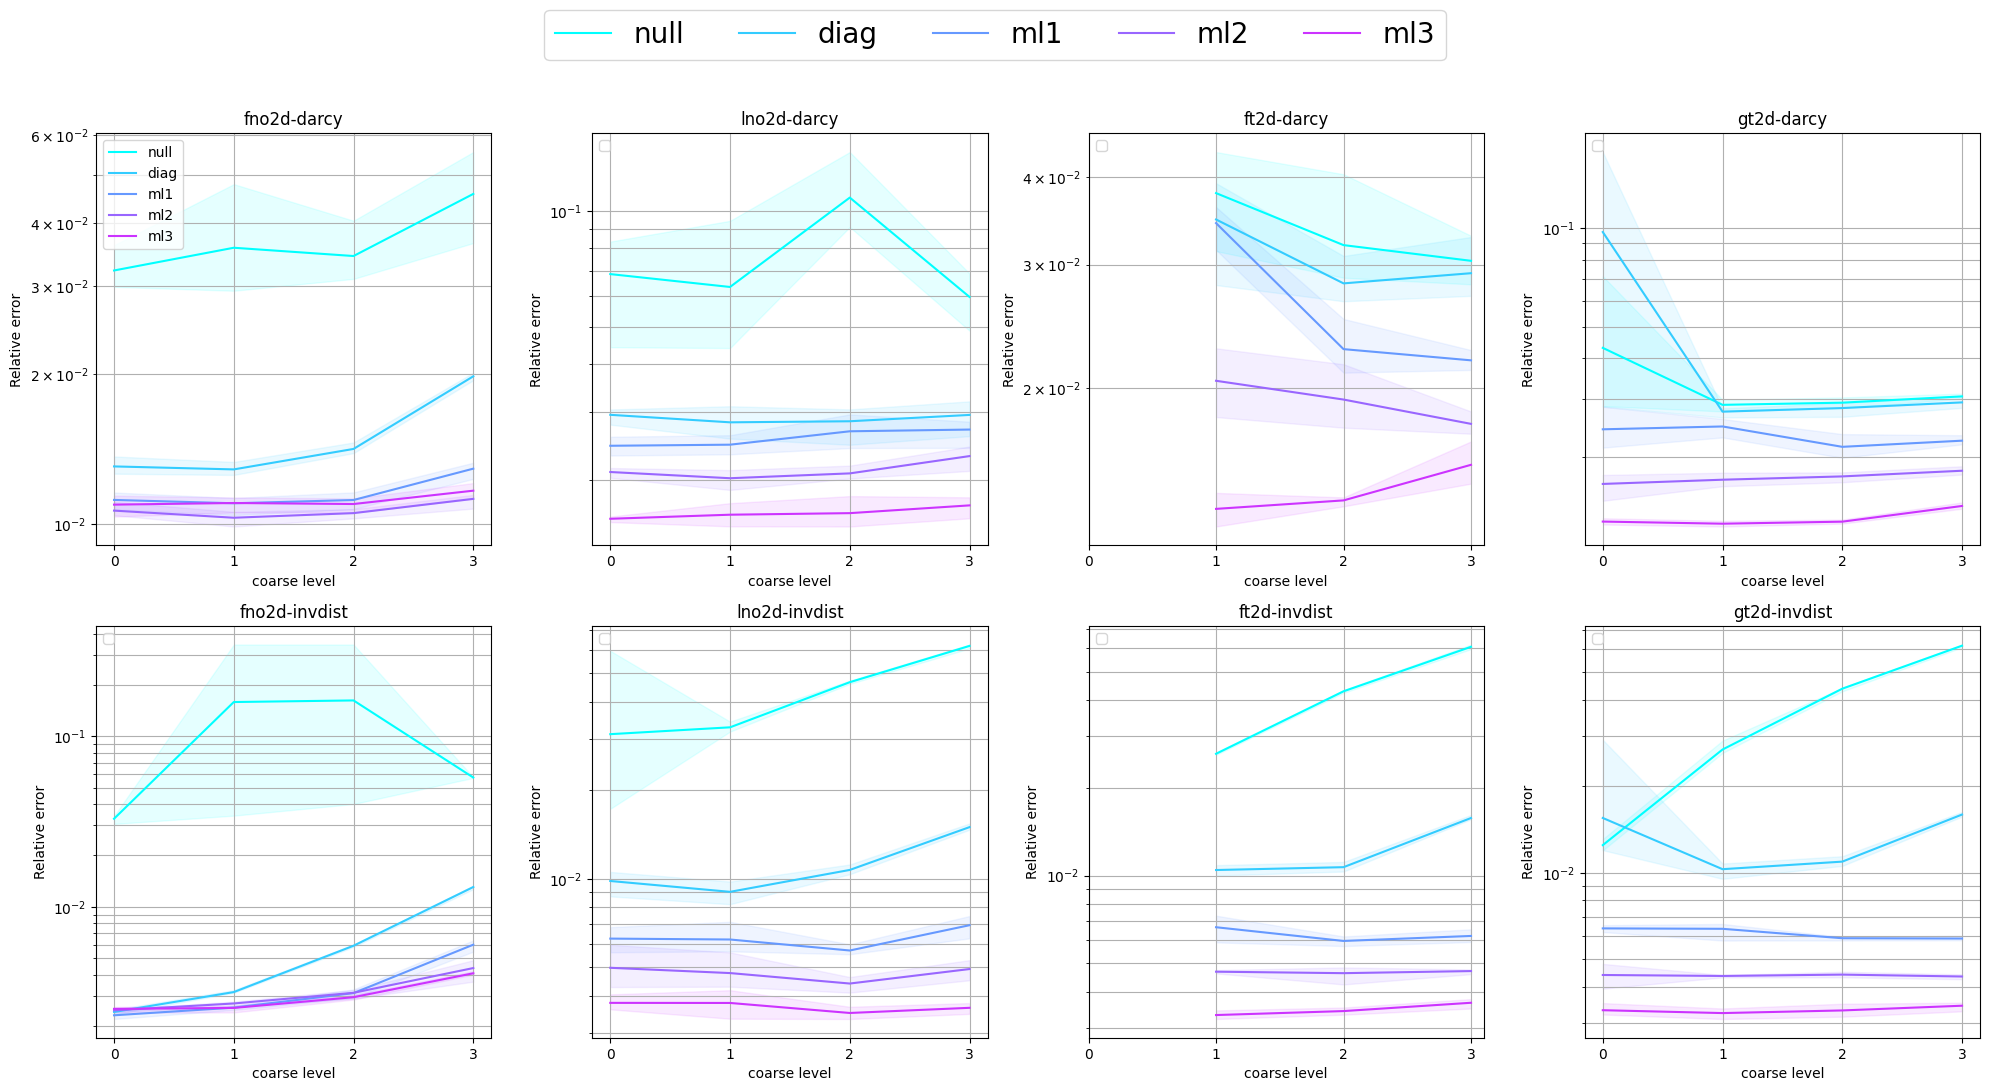

In [11]:
vis_acc_model_ds2d_ml_cl_fixres(log2d_filt_df, resolution=211)